In [2]:
import importlib
import re
import time
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import umap
import torch
import subprocess
import sys
import hdbscan
from bertopic import BERTopic
from joblib import Parallel, delayed
from langdetect import detect
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

#importlib.reload(src.fct_data)
import src
from src.fct_data import raw_data_cleaning, clean_prof
from src.fct_nlp import split_text_chunk
importlib.reload(src.fct_data)


model_name = "fr_core_news_sm"
try:
    nlp = spacy.load(model_name)
except OSError:
    print(f"Installation de {model_name}...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", model_name])
    nlp = spacy.load(model_name)

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Installation de fr_core_news_sm...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 500.6 kB/s  0:01:30eta 0:00:10
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


## Extraction des données



Traitement pour les 5 années disponibles sur le `gitlab` 

In [5]:
#on récupère un df avec métadonnées + texte nettoyé des stopwords
meta_et_texts = raw_data_cleaning("data/archelect_search.zip","data/text_files")

/home/onyxia/work/NLP_3A/src/fct_data.py:17: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  metadonnees = pd.read_csv("data/archelect_search.zip", compression="zip")


Traitement de data/text_files/1993/legislatives.zip
Traitement de data/text_files/1993/presidentielle.zip
Traitement de data/text_files/1973/legislatives.zip
Traitement de data/text_files/1988/legislatives.zip
Traitement de data/text_files/1981/legislatives.zip
Traitement de data/text_files/1978/legislatives.zip
Nombre total de documents extraits : 21697


In [6]:
print(meta_et_texts.shape)
print(meta_et_texts.columns)

(21697, 45)
Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'text',
       'zip_path', 'annee'],
      dtype='obj

In [7]:
meta_et_texts['contexte-election'].value_counts()

contexte-election
législatives    21167
Name: count, dtype: int64

We keep only the legislative elections.

In [6]:
meta_et_texts = meta_et_texts[meta_et_texts['contexte-election'] == 'législatives']

We do some final cleaning to make sure there will be not error when running our methods

In [7]:
meta_et_texts = meta_et_texts.dropna(subset=['text']) #remove lines without texts
meta_et_texts = meta_et_texts[meta_et_texts['text'].str.strip() != ''] #same for lines with empty text
meta_et_texts['annee'] = pd.to_datetime(meta_et_texts['date'], errors='coerce').dt.year

meta_et_texts = meta_et_texts.reset_index(drop=True)
df = meta_et_texts.copy()

In [8]:
print(df.shape)
df.head()

(21167, 45)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,text,zip_path,annee
0,EL196_L_1993_03_076_12_1_PF_01,1993-03-21,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1993, Seine-Maritime...",législatives,1.0,EL196,76,Seine-Maritime,76 - Seine-Maritime,...,maire,non mentionné,non mentionné,non mentionné,non mentionné,Alliance des Français pour le progrès,non,Département de Seine-Maritime 12ème Circonscri...,data/text_files/1993/legislatives.zip,1993
1,EL190_L_1993_03_024_02_1_PF_03,1993-03-21,Assemblée Nationale;Élections législatives;Fra...,"Élections législatives de 1993, Dordogne - 24,...",législatives,1.0,EL190,24,Dordogne,24 - Dordogne,...,conseiller général;maire,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,data/text_files/1993/legislatives.zip,1993
2,EL190_L_1993_03_017_01_1_PF_07,1993-03-21,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1993, Charente-Marit...",législatives,1.0,EL190,17,Charente-Maritime,17 - Charente-Maritime,...,non mentionné,non mentionné,non mentionné,non mentionné,Parti de la loi naturelle,non mentionné,non,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,data/text_files/1993/legislatives.zip,1993
3,EL192_L_1993_03_050_02_1_PF_03,1993-03-21,Élections législatives;France;Ve République;As...,"Élections législatives de 1993, Manche - 50, c...",législatives,1.0,EL192,50,Manche,50 - Manche,...,non mentionné,non mentionné,non mentionné,veuve,Verts;Génération écologie,Entente des écologistes,non,ENTENTE DES ECOLOGISTES Elections Législatives...,data/text_files/1993/legislatives.zip,1993
4,EL196_L_1993_03_079_04_1_PF_03,1993-03-21,Assemblée Nationale;Ve République;Élections lé...,"Élections législatives de 1993, Deux-Sèvres - ...",législatives,1.0,EL196,79,Deux-Sèvres,79 - Deux-Sèvres,...,élu municipal,non mentionné,environnement,non mentionné,Génération écologie;Verts,Entente des écologistes,non,Les Verts Confédération Écologiste Parti Écolo...,data/text_files/1993/legislatives.zip,1993


## 0/ Some descriptive statistics

In [9]:
print(f"Nombre de professions différentes répertoriées : {meta_et_texts['titulaire-profession'].nunique()}")
print("")
print("Liste :")
print(meta_et_texts['titulaire-profession'].value_counts())


counts = meta_et_texts['titulaire-profession'].value_counts()
nb_uniques = (counts == 1).sum()
total_professions = counts.shape[0]
pct_uniques = nb_uniques / total_professions * 100

print("")
print(f"Professions apparaissant une seule fois : {nb_uniques}")
print(f"Pourcentage : {pct_uniques:.2f}%")

Nombre de professions différentes répertoriées : 3397

Liste :
titulaire-profession
non mentionné                                             9465
professeur                                                 480
avocat                                                     368
chef d'entreprise                                          234
ingénieur                                                  232
                                                          ... 
ouvrier affûteur                                             1
notaire rural;professeur droit rural Ecole de notariat       1
chirurgien Centre hospitalier                                1
travailleuse foyer                                           1
technicien gestion industrielle                              1
Name: count, Length: 3397, dtype: int64


In [ ]:
print(f"Nombre de professions différentes répertoriées : {meta_et_texts['titulaire-profession'].nunique()}")
print("")
print("Liste :")
print(meta_et_texts['titulaire-profession'].value_counts())


Nombre de partis différents répertoriés : 907


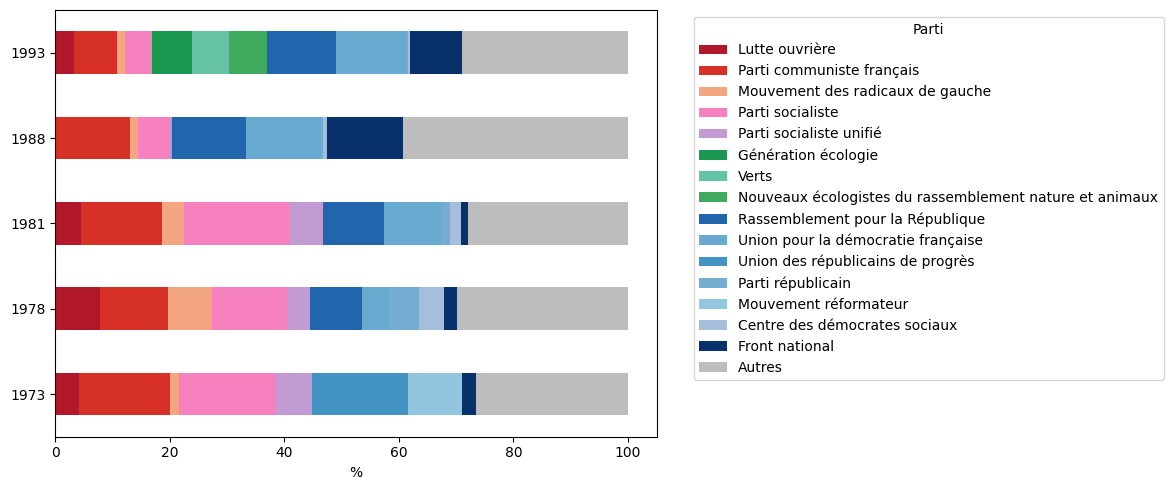

In [16]:
df = meta_et_texts.dropna(subset=['titulaire-soutien']).copy()
df['annee'] = pd.to_datetime(df['date']).dt.year


df['partis_list'] = df['titulaire-soutien'].str.split(';')
df['partis_list'] = df['partis_list'].apply(lambda x: [p.strip() for p in x])

df_exploded = df.explode('partis_list')
df_exploded = df_exploded[df_exploded['partis_list'] != 'non mentionné']

print(f"Nombre de partis différents répertoriés : {df_exploded['partis_list'].nunique()}")

top = df_exploded['partis_list'].value_counts().head(15).index

#autre qui si aucun soutien d'un des 10 plus grand partis 
def filtrer_partis(partis):
    partis_top = [p for p in partis if p in top]
    if len(partis_top) > 0:
        return partis_top 
    else:
        return ['Autres'] 

df['partis_filtres'] = df['partis_list'].apply(filtrer_partis)

df_final = df.explode('partis_filtres')

table = pd.crosstab(df_final['annee'], df_final['partis_filtres'])
table_pct = table.div(table.sum(axis=1), axis=0) * 100
table_pct = table_pct[top.tolist() + ['Autres']]

#plot
ordre_politique = [
    # Extrême gauche
    'Lutte ouvrière',
    'Parti communiste français',
    # Gauche / centre gauche
    'Mouvement des radicaux de gauche',
    'Parti socialiste',
    'Parti socialiste unifié',
    # Écologistes
    'Génération écologie',
    'Verts',
    'Nouveaux écologistes du rassemblement nature et animaux',
    # Centre / centre droit
    'Rassemblement pour la République',
    'Union pour la démocratie française',
    'Union des républicains de progrès',
    'Parti républicain',
    'Mouvement réformateur',
    'Centre des démocrates sociaux',
    # Extrême droite
    'Front national',
    # Autres
    'Autres'
]

# Mapping de couleurs pour ces 15 partis + Autres
colors = {
    "Parti communiste français": "#d73027",      # rouge vif
    "Lutte ouvrière": "#b2182b",                 # rouge foncé
    "Mouvement des radicaux de gauche": "#f4a582", # rose-orangée
    "Parti socialiste": "#f781bf",               # rose
    "Parti socialiste unifié": "#c39bd3",        # violet clair / rose violet
    "Génération écologie": "#1a9850",            # vert
    "Verts": "#66c2a5",                          # vert clair
    "Nouveaux écologistes du rassemblement nature et animaux": "#41ab5d", # vert foncé
    "Rassemblement pour la République": "#2166ac",  # bleu droite gaulliste
    "Union pour la démocratie française": "#67a9cf", # bleu clair
    "Union des républicains de progrès": "#4393c3", # bleu intermédiaire
    "Front national": "#08306b",                 # bleu marine
    "Parti républicain": "#74add1",              # bleu clair / centre droit
    "Mouvement réformateur": "#92c5de",          # bleu pâle
    "Centre des démocrates sociaux": "#a6bddb",  # bleu très clair
    "Autres": "#bdbdbd"                          # gris
}

table_pct = table_pct[ordre_politique]
table_pct.plot(
    kind='barh',        
    stacked=True,
    figsize=(12,5),
    color=[colors.get(col, "#cccccc") for col in table_pct.columns]
)

#plt.title("Répartition des partis (top 10 + Autres) par année (%)")
plt.ylabel("")
plt.xlabel("%")
plt.legend(title="Parti", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Statistics on the texts

In [11]:
lengths = df['text'].str.split().str.len()

print("Number of texts: ",df.shape[0])
print("Average nb of words per text :", lengths.mean())
print("Median nb of words per text:", lengths.median())
print("Max :", lengths.max())
print("Min :", lengths.min())

Number of texts:  21167
Average nb of words per text : 688.8839703311759
Median nb of words per text: 616.0
Max : 3870
Min : 10


## 1/ Thematic analysis
We propose and compare 2 approches : (i) Non-negative matrix factorisation, (ii) Topic modeling with embeddings : Bertopic


#### (i) Non-negative matrix factorisation

In [21]:
# lemmatisation : 6 min pour 1 election
# python -m spacy download fr_core_news_sm A INSTALLER A LA PREMIERE UTILISATION
# ligne ci-dessus normalement gérée par un ajout sur la tte premiere cellule du notebook

start_load = time.time()

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
print(f"Modèle chargé en {time.time() - start_load:.2f}s\n")

def lemmatize_batch(texts, batch_size=1000):
    total_docs = len(texts)
    print(f"Début de la lemmatisation de {total_docs} documents\n")

    start_total = time.time()
    results = []

    processed = 0

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=2):
        lemmas = " ".join(
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha and len(token) > 2
        )
        results.append(lemmas)

        processed += 1

        # print tous les 1000 docs
        if processed % 1000 == 0:
            elapsed = time.time() - start_total
            speed = processed / elapsed
            print(f"{processed}/{total_docs} docs | {speed:.1f} docs/sec | {elapsed/60:.2f} min")

    total_time = time.time() - start_total

    print("\nLemmatisation terminée")
    print(f"Documents traités : {total_docs}")
    print(f"Temps total : {total_time/60:.2f} min")

    return results


# Application
df['lemmatized_text'] = lemmatize_batch(df['text'].tolist())

Modèle chargé en 0.82s

Début de la lemmatisation de 21167 documents



Process Process-1:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/opt/python/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/spacy/language.py", line 2412, in _apply_pipes
    byte_docs = [(doc.to_bytes(), doc._context, None) for doc in docs]
                                                                 ^^^^
  File "/opt/python/lib/python3.13/site-packages/spacy/util.py", line 1763, in _pipe
    yield from proc.pipe(docs, **kwargs)
  File "spacy/pipeline/pipe.pyx", line 48, in pipe
  File "/opt/python/lib/python3.13/site-packages/spacy/util.py", line 1763, in _pipe
    yield from proc.pipe(docs, **kwargs)
  File "spacy/pipeline/pipe.pyx", line 48, in pipe
    for doc in stream:
  File "/opt/python/lib/python3.13/site-p

KeyboardInterrupt: 

On sauvegarde les données intermédiaires pour gagner du temps dans l'exécution et pouvoir les récupérer directement depuis data/inter

In [ ]:
df["identifiant de circonscription"] = df["identifiant de circonscription"].astype(str)

In [ ]:
#df.to_parquet("data/inter/df_lemmatized_5elec.parquet", engine="pyarrow", index=False, compression="snappy")
df = pd.read_parquet("data/inter/df_lemmatized_5elec.parquet")

In [48]:
# NMF global (tous élections confondues)
N_TOPICS = 6

#stopwords 
custom_stopwords = [
    # Mots génériques non thématiques
    "monsieur", "madame", "politique", "france", "français", "françaises",
    "faire", "être", "avoir", "falloir", "pouvoir", "devoir",
    "ici", "nom", "vie", "année","bulletin","pays","électeur","liste",
    "député","gauche","droite","majorité","parti","juin","gouvernement",
    "maire","président","marseille", "vote",
    
    # Étiquettes de partis / personnes
    "rpr", "udf", "communiste", "socialiste", "ecologiste", "écologiste",
    "lepen", "mitterrand", "ruffi","françois","mitterrand",
    "front", "national", 
] + stopwords.words('french') + stopwords.words('german')


In [49]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.4,   #  on supprime les mots présents dans plus de la moitié des textes
    min_df=15,     # on supprime ceux dans moins de 15 textes
    max_features = 20000, #on limite la taille des mots à enregistrer
    stop_words=custom_stopwords,  
)
print('ok def tfidf')
tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])
print('tf-idf fini')
# Non-negative matrix factorisation
nmf = NMF(n_components=N_TOPICS, random_state=2026)
W = nmf.fit_transform(tfidf)
H = nmf.components_
print(' NMF fini')

# Affichage des mots par topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in np.argsort(-topic)[:20]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}\n")

# Normalisation
W_normalized = W / W.sum(axis=1, keepdims=True)
df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['topic_score']    = np.max(W_normalized, axis=1)

# Ajout des poids au dataframe
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

ok def tfidf
tf-idf fini
 NMF fini
Topic 0: changement, commun, tour, général, progrès, développement, service, action, permettre, ensemble, région, assurer, public, problème, choix, formation, assemblée, économie, non, département

Topic 1: travailleur, lutte, petit, femme, marchais, ouvrier, entendre, bombe, atomique, ouvrière, commerçant, ouvriere, paysan, laguiller, travailleuses, arlette, travailleurs, avertissement, parlement, dire

Topic 2: animaux, nature, rassemblement, existence, activité, corrida, accés, vivisection, compléte, minimun, panorama, gratuitement, véto, feuille, trèfle, documentation, découper, spirituel, abattoir, animal

Topic 3: immigration, rétablir, impôt, carte, million, sauver, immigré, supprimer, nationalité, séjour, corruption, main, traité, renouvelable, proteger, rien, voix, code, insécurité, vérité

Topic 4: redressement, conviction, suppression, populaire, payent, fiscalist, absent, trafiquant, octroi, hégémonie, assassin, antisocialiste, apprêter, j

In [50]:
# labels input
topic_label = {
    0: "appel à l'alternance",
    1: "protection de l'environnement et des animaux",
    2: 'libéralisme/fiscalité',
    3: 'immigration',
    4: 'lutte sociale', 
    5: 'écologie et générations futures'
}

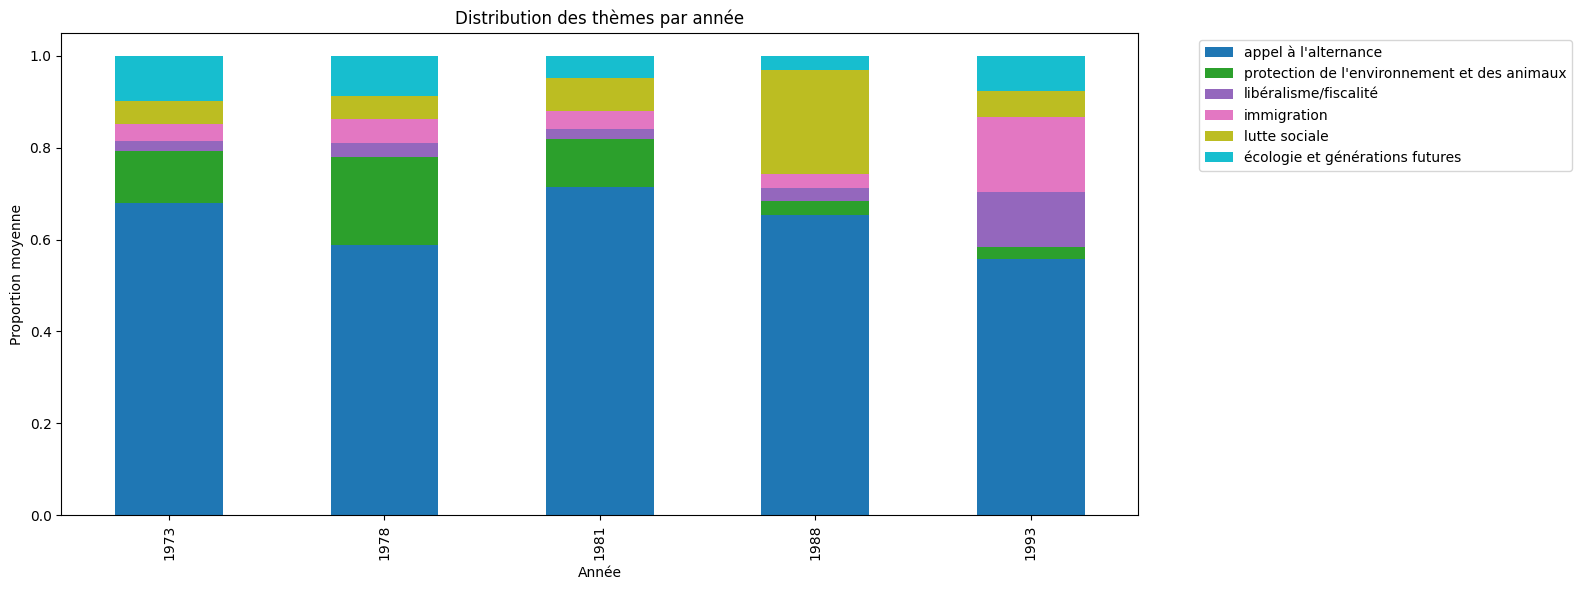

In [51]:
# topics / doc 
W_normalized = W / W.sum(axis=1, keepdims=True)

df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['dominant_label'] = df['dominant_topic'].map(topic_label)
df['topic_score']    = np.max(W_normalized, axis=1)

# topic distrib / year 
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]

# ajout colonnes
df = df.drop(columns=[col for col in df.columns if col.startswith('topic_')], errors='ignore')
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

topic_by_year = df.groupby('annee')[topic_cols].mean()

topic_by_year.rename(
    columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
).plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année")
plt.ylabel("Proportion moyenne")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [53]:
#df.to_parquet("data/inter/df_nmf_5elec.parquet", engine="pyarrow", index=False, compression="snappy")

In [17]:
df = pd.read_parquet("data/inter/df_nmf_5elec.parquet")

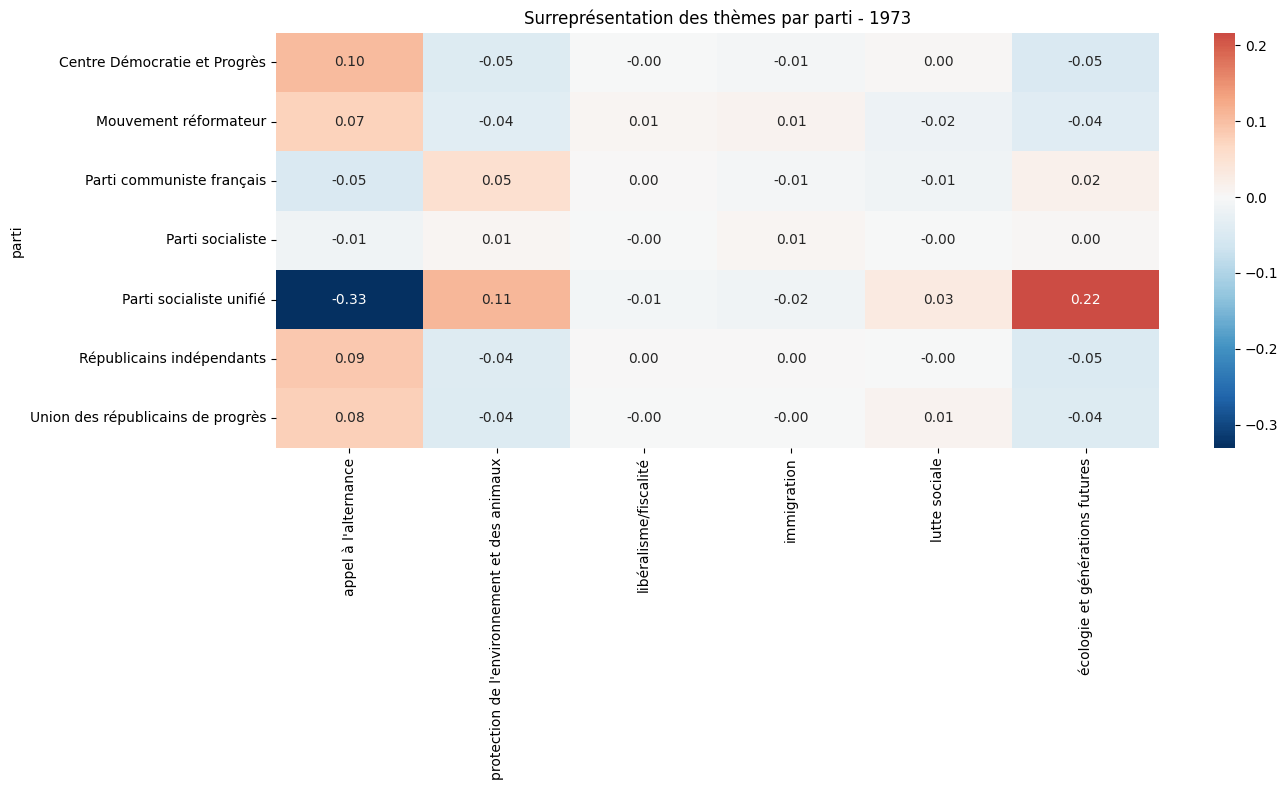

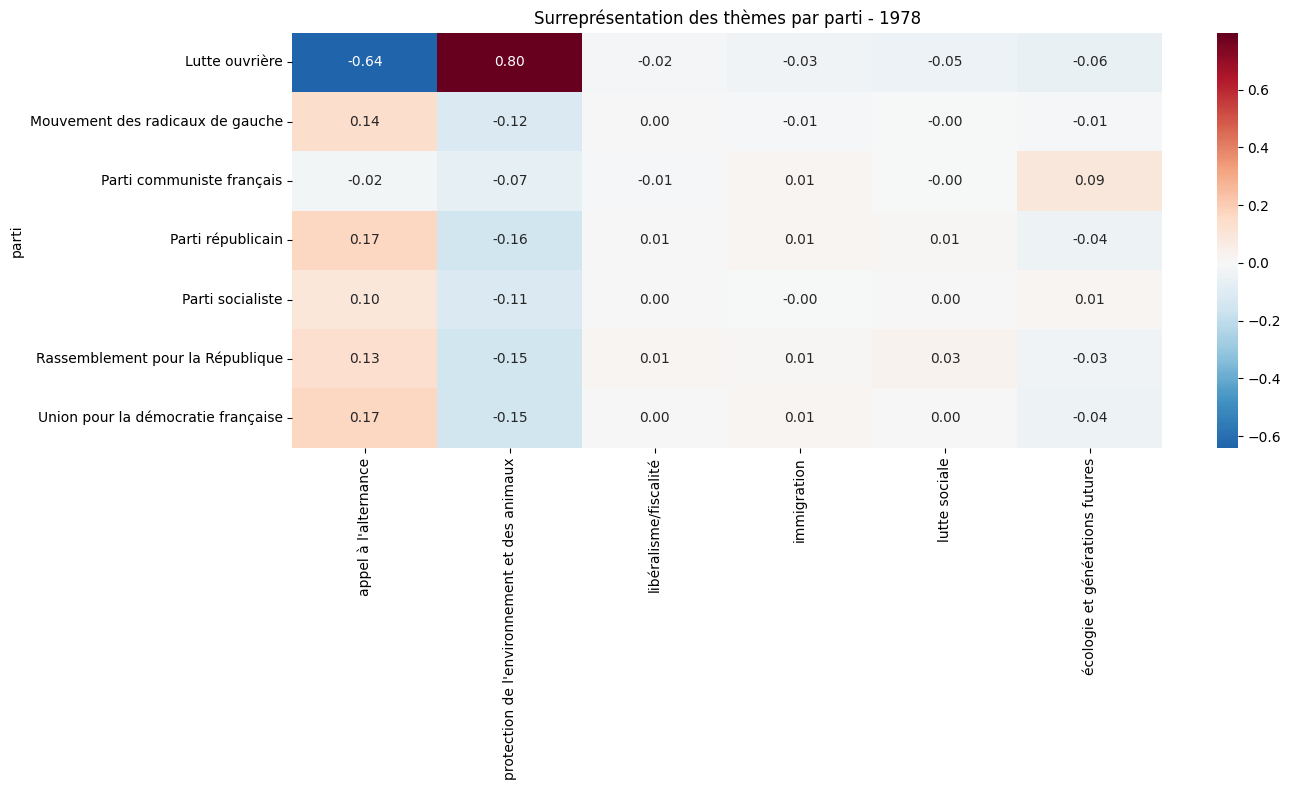

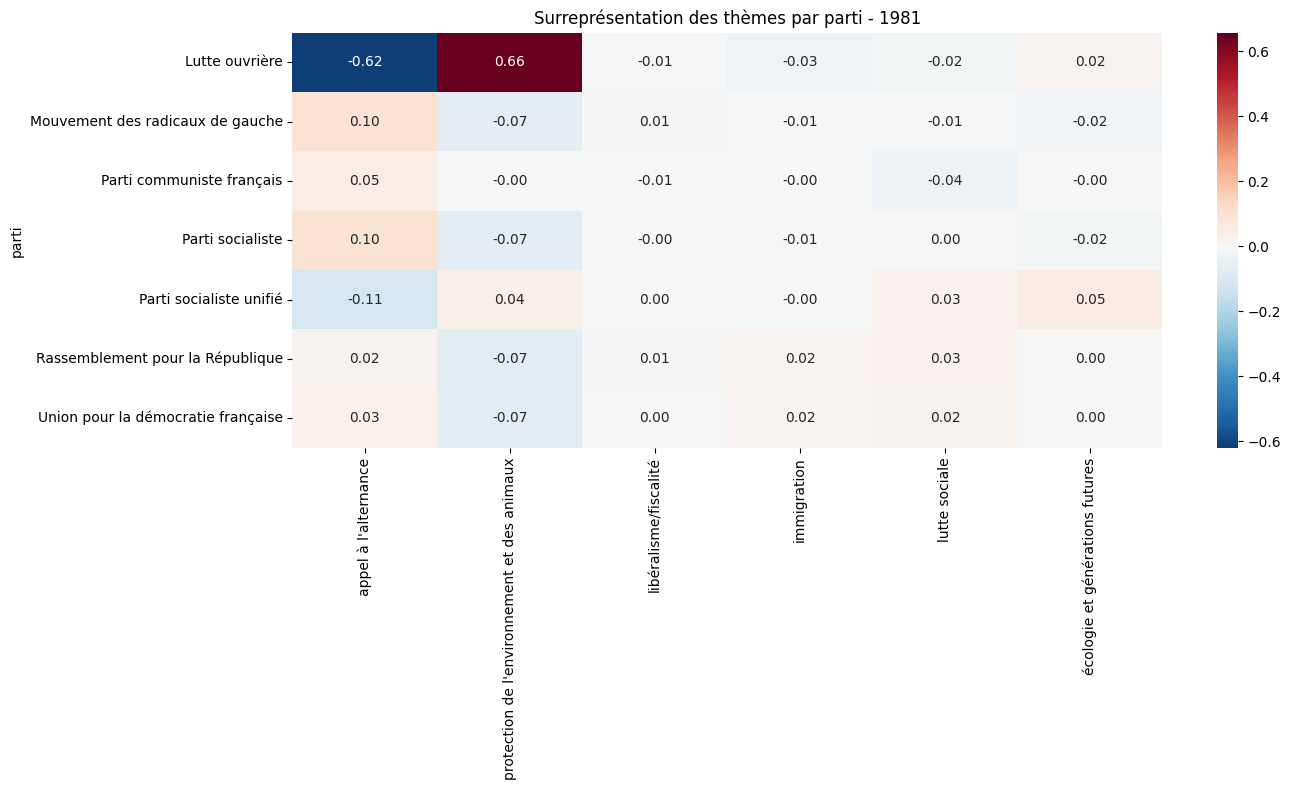

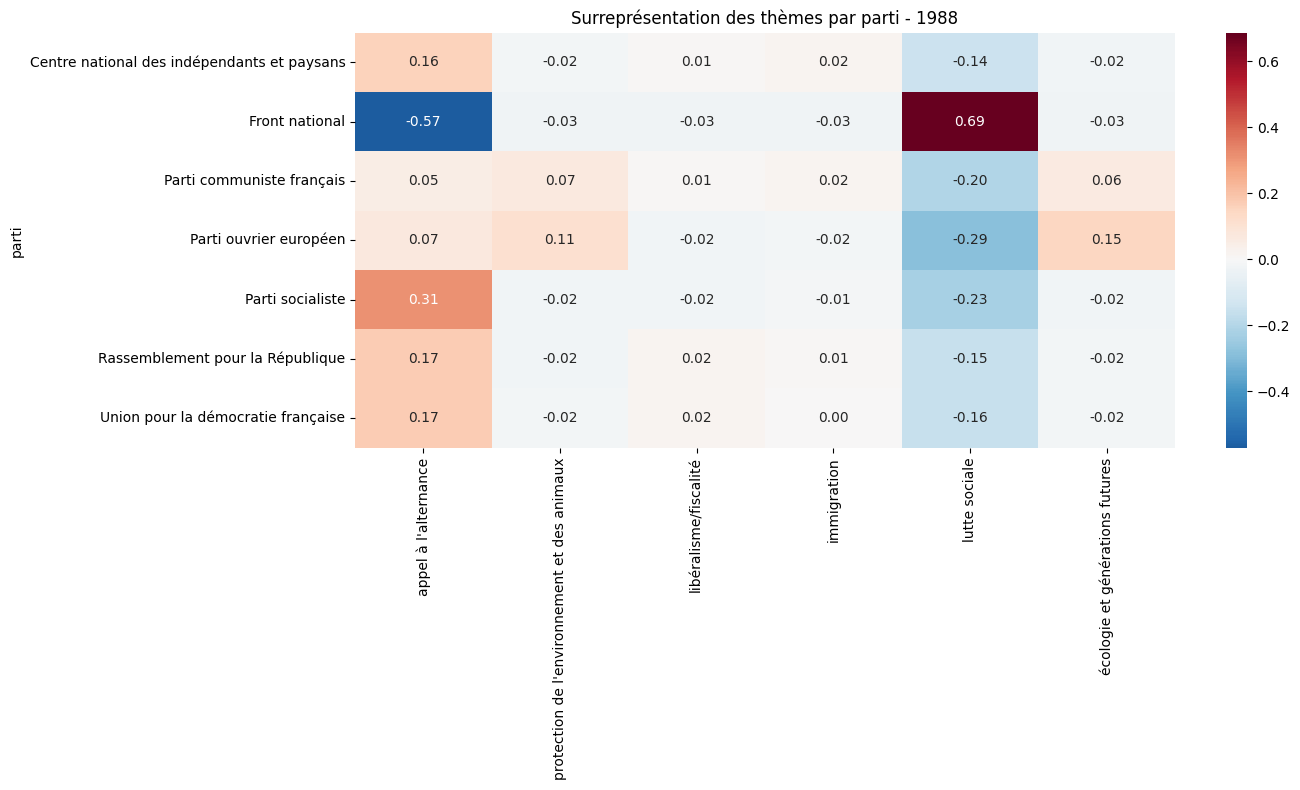

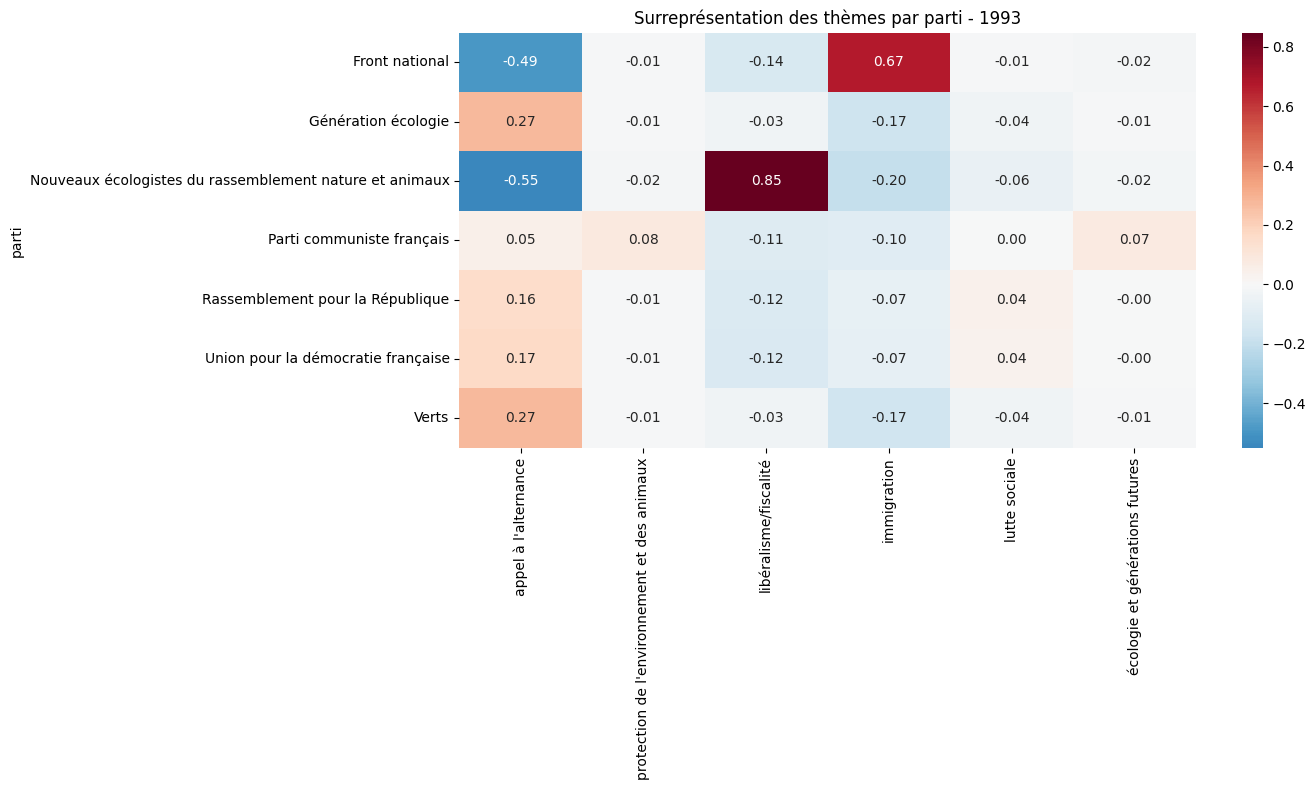

In [ ]:
    # créer un DataFrame explosé pour les partis
    df_exploded = df.copy()
    df_exploded['parti'] = df_exploded['titulaire-soutien'].str.split(';')
    df_exploded = df_exploded.explode('parti')
    df_exploded['parti'] = df_exploded['parti'].str.strip()
    df_exploded = df_exploded[df_exploded['parti'].notna()]
    df_exploded = df_exploded[df_exploded['parti'] != "non mentionné"]
    df_exploded = df_exploded[df_exploded['parti'] != ""]

    # boucle par année
    for year, df_year in df_exploded.groupby('annee'):

        # compter les partis pour cette année et garder top nb_partis
        nb_partis = 7
        parti_counter = Counter(df_year['parti'])
        top_partis = [p for p, _ in parti_counter.most_common(nb_partis)]
        df_top = df_year[df_year['parti'].isin(top_partis)]

        # calcul surreprésentation
        global_mean = df_top[topic_cols].mean()
        topic_by_parti = df_top.groupby('parti')[topic_cols].mean()
        surreprésentation = topic_by_parti - global_mean

        # heatmap
        plt.figure(figsize=(14, 8))
        sns.heatmap(
            surreprésentation.rename(
                columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
            ),
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt='.2f'
        )
        plt.title(f"Surreprésentation des thèmes par parti - {year}")
        plt.tight_layout()
        plt.show()

#### (ii) Topic modeling with embeddings : Bertopic

In [12]:
# embeddings //
#les deux ci-dessous donnent quasi exactement les mêmes résultats
#embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 659.16it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
#we assign an id to each doc for merge much later
df = df.reset_index(drop=True)
df["doc_id"] = df.index

#we get the docs under list form
docs = df['text'].tolist()

We have to consider that our texts are too long for sentence-camenbert, and the encoder must be use with texts no longer than 512 tokens.

In [14]:
#we divide our texts using our split_function to avoid too long texts (that would be over then 512 tokens-limit)
docs_segmented = []
doc_ids = []

for i, doc in enumerate(docs):
    segments = split_text_chunk(doc)
    docs_segmented.extend(segments)
    doc_ids.extend([i] * len(segments))

In [15]:
import torch
torch.set_num_threads(1)

num_cores  = 4
batch_size = 64
chunk_size = 512
chunks = [docs_segmented[i:i+chunk_size] for i in range(0, len(docs_segmented), chunk_size)]
num_chunks = len(chunks)
print(f"Nombre total de chunks : {num_chunks}")
print(f"Embeddings générés pour {len(docs_segmented)} segments")

Nombre total de chunks : 122
Embeddings générés pour 62309 segments


We tried two different methodes to encode this large dataset : letting the encoding being optimized by itself and parallelizing it ourself. In the end, it is almost faster with our parallelisation. 

In [17]:
def encode_chunk(chunk, chunk_idx):
    start      = time.time()
    embeddings_old = embedding_model.encode(chunk, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    elapsed    = time.time() - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings_old, elapsed

start_total_chunk = time.time()

results = Parallel(n_jobs=num_cores, prefer="processes")(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

embeddings_old = np.vstack([res[0] for res in results])
total_time_chunk = time.time() - start_total_chunk

print(f"\n Embeddings générés pour {len(docs)} textes")
print(f"Shape : {embeddings_old.shape}")
print(f"Temps total : {total_time_chunk/60:.2f} minutes")

Batches:  69%|██████▉   | 11/16 [00:18<00:08,  1.76s/it]

✅ Chunk 1/122 traité en 23.30s


Batches: 100%|██████████| 16/16 [00:25<00:00,  1.59s/it]


✅ Chunk 2/122 traité en 25.42s


Batches: 100%|██████████| 16/16 [00:27<00:00,  1.73s/it]


...

Batches: 100%|██████████| 12/12 [00:11<00:00,  1.08it/s]


✅ Chunk 122/122 traité en 11.14s


Batches:  94%|█████████▍| 15/16 [00:14<00:00,  1.08it/s]

✅ Chunk 121/122 traité en 14.94s

 Embeddings générés pour 21167 textes
Shape : (62309, 768)
Temps total : 12.86 minutes


Batches: 100%|██████████| 16/16 [00:14<00:00,  1.07it/s]


In [19]:
#nltk.download('stopwords')
STOPWORDS = stopwords.words('french')+stopwords.words('german')
STOPWORDS = list(set(STOPWORDS))

In [20]:
# UMAP : to reduce the dimensions of the embedding

umap_model = umap.UMAP(
    n_neighbors=5,
    min_dist=0.0,
    n_components=5,
    random_state=42,
    n_jobs=8,
    verbose = True
)

# hdbscan : to get clusters
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20,
    cluster_selection_epsilon=0.01,
    core_dist_n_jobs=8,
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    min_df=3
)

In [21]:
# --- BERTOPIC setup ---
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='french',
    nr_topics=None,  # laisser BERTopic décider
    calculate_probabilities=True,
    verbose=True
)

# --- Fit sur les segments ---
topics_segments, probs_segments = topic_model.fit_transform(docs_segmented, embeddings=embeddings_old)

# --- Assigner topic dominant à chaque doc ---
df_segments = pd.DataFrame({
    "doc_id": doc_ids,  # correspond à chaque segment
    "topic": topics_segments,
    "score": probs_segments.max(axis=1)
})

# topic dominant par doc
df_doc = df_segments.groupby("doc_id").agg({
    "topic": lambda x: x.value_counts().index[0],  # topic le plus fréquent
    "score": "max"                                 # score max parmi les segments
}).reset_index()

# --- Réduction de topics sur les segments ---
topic_model.reduce_topics(docs_segmented, nr_topics=10)
topics_reduced, probs_reduced = topic_model.transform(docs_segmented, embeddings=embeddings_old)

# --- Assigner topics réduits à chaque doc ---
df_segments["topic_reduced"] = topics_reduced
df_segments["score_reduced"] = probs_reduced.max(axis=1)

# topic réduit dominant par doc
df_doc_reduced = df_segments.groupby("doc_id").agg({
    "topic_reduced": lambda x: x.value_counts().index[0],
    "score_reduced": "max"
}).reset_index()

# --- Fusion with the final dataset --
df = df.merge(df_doc_reduced, left_on="doc_id", right_on="doc_id", how="left")
df.rename(columns={
    "topic_reduced": "BERTopic_dominant",
    "score_reduced": "BERTopic_score"
}, inplace=True)

# --- Vérification finale ---
print(topic_model.get_topic_info())

2026-04-17 19:50:01,948 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


UMAP(min_dist=0.0, n_components=5, n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Fri Apr 17 19:50:02 2026 Construct fuzzy simplicial set
Fri Apr 17 19:50:02 2026 Finding Nearest Neighbors
Fri Apr 17 19:50:02 2026 Building RP forest with 17 trees
Fri Apr 17 19:50:11 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	Stopping threshold met -- exiting after 5 iterations
Fri Apr 17 19:50:27 2026 Finished Nearest Neighbor Search
Fri Apr 17 19:50:32 2026 Construct embedding


Epochs completed:   2%| ▏          4/200 [00:01]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         23/200 [00:03]

...

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:28]


Fri Apr 17 19:51:20 2026 Finished embedding


2026-04-17 19:51:20,742 - BERTopic - Dimensionality - Completed ✓
2026-04-17 19:51:20,747 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-17 20:11:05,577 - BERTopic - Cluster - Completed ✓
2026-04-17 20:11:05,597 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-17 20:11:15,411 - BERTopic - Representation - Completed ✓
2026-04-17 20:11:23,469 - BERTopic - Topic reduction - Reducing number of topics
2026-04-17 20:11:23,524 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-17 20:11:33,817 - BERTopic - Representation - Completed ✓
2026-04-17 20:11:33,830 - BERTopic - Topic reduction - Reduced number of topics from 458 to 10
2026-04-17 20:11:34,559 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-17 20:11:34,874 - BERTopic - Dimensionality - Completed ✓
2026-04-17 20:11:34,875 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-17 20:1

   Topic  Count                                     Name  \
0     -1  32164   -1_plus_politique_tous_circonscription   
1      0  27556           0_plus_ans_gauche_travailleurs   
2      1   1084          1_mehr_leben_unserer_frankreich   
3      2    560  2_animaux_nature_nouveaux_rassemblement   
4      3    334           3_tout_travailleurs_si_promets   
5      4    165        4_peuvent_politiques_idéal_vivent   
6      5    135       5_accepter_illusion_pouvons_triage   
7      6    131      6_alliance_préjugés_naître_désastre   
8      7    124                          7_no_nei_ia_mau   
9      8     56            8_75561_dislocation_câble_nac   

                                      Representation  \
0  [plus, politique, tous, circonscription, franc...   
1  [plus, ans, gauche, travailleurs, tous, politi...   
2  [mehr, leben, unserer, frankreich, elsass, wäh...   
3  [animaux, nature, nouveaux, rassemblement, exi...   
4  [tout, travailleurs, si, promets, entendra, at...   
5  

In [ ]:
#df["identifiant de circonscription"] = df["identifiant de circonscription"].astype(str)
#df.to_parquet("data/inter/df_resultat_BERT.parquet", engine="pyarrow", index=False, compression="snappy")

In [24]:
topic_model.visualize_barchart(top_n_topics=10) 

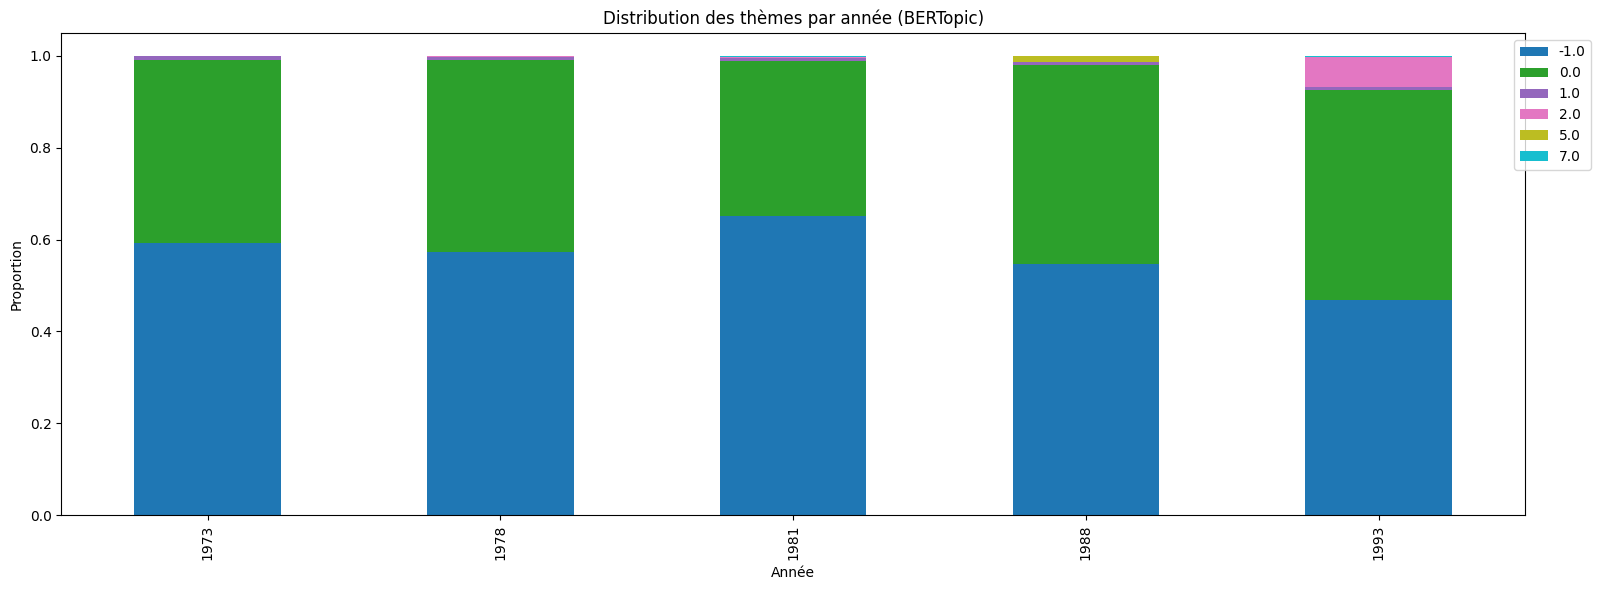

In [25]:
#distrib topic par année
topic_info = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()

topic_by_year = df.groupby(['annee', 'BERTopic_dominant']).size().unstack(fill_value=0)
topic_by_year = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)  # normalisation

topic_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année (BERTopic)")
plt.ylabel("Proportion")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Classification par thème (suite ii bis BERT caroline)

Ci-dessous, on transforme notre embedding en vecteurs de bcp plus petite dimension (environ 20 sec avec ces paramètre d'UMAP)

In [32]:
umap_embeddings = umap.UMAP(
    n_neighbors=15, min_dist=0.3, n_components=5, random_state=42, verbose = True
).fit_transform(embeddings)
print(f"UMAP embeddings shape: {umap_embeddings.shape}")

UMAP(min_dist=0.3, n_components=5, n_jobs=1, random_state=42, verbose=True)
Sat Mar 28 16:17:56 2026 Construct fuzzy simplicial set
Sat Mar 28 16:17:56 2026 Finding Nearest Neighbors
Sat Mar 28 16:17:56 2026 Building RP forest with 10 trees
Sat Mar 28 16:17:56 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Sat Mar 28 16:17:58 2026 Finished Nearest Neighbor Search
Sat Mar 28 16:17:58 2026 Construct embedding


Epochs completed:   3%| ▎          6/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         23/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▎ 185/200 [00:11]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:12]


Sat Mar 28 16:18:11 2026 Finished embedding
UMAP embeddings shape: (11702, 5)


DBScan ci-dessous va créer des clusters thématiques

In [34]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100,
                            min_samples=10,  # moins strict sur la densité
                            cluster_selection_method='leaf')
#on ajoute à notre dataframe le thème abordé par le candidat
meta_et_texts_metier['theme_cluster'] = clusterer.fit_predict(umap_embeddings)
print(f"Clusters trouvés : {meta_et_texts_metier['theme_cluster'].nunique()} (le -1 correspond aux outliers)")


Clusters trouvés : 14 (le -1 correspond aux outliers)


On essaie de labelliser les thèmes automatiquement

In [36]:
#on reliste tous les mots éliminés
all_stopwords = stopwords_fr.union(top_20_words)

# Function to get the "op words" per cluster
def get_top_words_filtered(texts, n=10):
    # put together all words in the cluster
    all_words = " ".join(texts).lower().split()
    # Remove all the words from the stowords list
    all_words = [w for w in all_words if w not in all_stopwords]
    # counting
    return Counter(all_words).most_common(n)

# Go through all clusters
for cluster_id in sorted(meta_et_texts_metier['theme_cluster'].unique()):
    if cluster_id == -1:  # ignore outliers if needed
        continue
    texts = meta_et_texts_metier[meta_et_texts_metier['theme_cluster'] == cluster_id]['texte_clean']  # utiliser la colonne filtrée
    top_words = get_top_words_filtered(texts,15)
    print(f"Cluster {cluster_id}: {top_words}")

Cluster 0: [('suppléant', 2279), ('lutte', 1403), ('progrès', 1019), ('candidats', 898), ('vote', 888), ('etat', 768), ('voter', 762), ('avertissement', 756), ('ouvrier', 642), ('révolutionnaires', 640), ('tour', 638), ('ouvriere', 630), ('ouvrière', 525), ('e', 524), ('gouvernement', 516)]
Cluster 1: [('national', 1957), ('front', 1614), ('vote', 1289), ('nationale', 1241), ('avenir', 919), ('rpr', 917), ('udf', 916), ('force', 915), ('votez', 645), ('populaire', 617), ('contre', 614), ('suppression', 614), ('convictions', 614), ('députés', 613), ('ici', 613)]
Cluster 2: [('voter', 2114), ('mitterrand', 1844), ('petits', 1483), ('contre', 1482), ('marchais', 1449), ('droite', 1271), ('lutte', 1267), ('femmes', 1065), ('travailleuses', 1056), ('gouvernement', 894), ('candidats', 855), ('hommes', 850), ('politiques', 822), ('commerçants', 813), ('ouvriere', 714)]
Cluster 3: [('voter', 1339), ('mitterrand', 1168), ('contre', 938), ('petits', 937), ('marchais', 888), ('droite', 804), ('fe

## 2/ Croisement avec les professions des candidats


There are over 3000 different occupations, with no established classification system or nomenclature; we will therefore also use embedding and clustering to assign candidates to a broader occupational category

### NOUVELLE METHODE
For each work in df_pred, we compute the textual similarity with the name of socio-professional categories

In [18]:
#focus on candidates with declared work
df_metier = df[df['titulaire-profession'] != "non mentionné"].copy()
df_metier.shape

(11702, 54)

In [19]:
#small cleaning for jobs
professions = df_metier['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    # we delete the ";" that separates the different professions declared by the same candidate
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

3383

In [20]:
df_pcs = pd.read_csv("data/insee/insee_PCS2020_4.csv", sep=";")
df_pcs[df_pcs["Niveau"]==1]

,Niveau,code PCS2020,Libellé long de la nomenclature,libellé court – nomenclature d’usage
0,1,1000,Agriculteurs exploitants,Agriculteurs
14,1,2000,"Artisans, commerçants et chefs d’entreprise","Artisans, commerçants et chefs d’entreprise"
65,1,3000,Cadres et professions intellectuelles supérieures,Cadres
172,1,4000,Professions intermédiaires,Professions intermédiaires
279,1,5000,Employés,Employés
361,1,6000,Ouvriers,Ouvriers


In [21]:
model_professions = SentenceTransformer("dangvantuan/sentence-camembert-base")
embeddings_professions = model_professions.encode(unique_professions,
                                                batch_size=256,
                                                show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 459.06it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [00:58<00:00,  4.15s/it]


In [22]:
pcs_n4 = df_pcs[df_pcs["Niveau"] == 4]
pcs_labels = pcs_n4["Libellé long de la nomenclature"].tolist()
pcs_embeddings = model_professions.encode(pcs_labels)

In [23]:
#normalisation
pcs_emb_norm = normalize(pcs_embeddings)
prof_emb_norm = normalize(embeddings_professions)

In [24]:
#similarity
sim = cosine_similarity(prof_emb_norm, pcs_emb_norm)
best_match_idx = sim.argmax(axis=1)
best_scores = sim.max(axis=1)

#attribution pcs4
df_pred = pd.DataFrame({
    "profession": unique_professions,
    "pcs_n4_code": pcs_n4.iloc[best_match_idx]["code PCS2020"].values,
    "score": best_scores
})

#remontée pcs 1
df_pred['pcs_n1_code'] = df_pred['pcs_n4_code'].str[0]
df_pred['pcs_n2_code'] = df_pred['pcs_n4_code'].str[:2]
df_pcs_filtered = df_pcs[df_pcs['Niveau'].isin([1, 2])].copy()
df_pcs_filtered.loc[df_pcs_filtered['Niveau'] == 1, 'code_reduit'] = df_pcs_filtered.loc[df_pcs_filtered['Niveau'] == 1, 'code PCS2020'].astype(str).str[0]
df_pcs_filtered.loc[df_pcs_filtered['Niveau'] == 2, 'code_reduit'] = df_pcs_filtered.loc[df_pcs_filtered['Niveau'] == 2, 'code PCS2020'].astype(str).str[:2]
pcs_dict = df_pcs_filtered.set_index('code_reduit')['libellé court – nomenclature d’usage'].to_dict()
df_pred['pcs_n1_lib'] = df_pred['pcs_n1_code'].map(pcs_dict)
df_pred['pcs_n2_lib'] = df_pred['pcs_n2_code'].map(pcs_dict)


In [25]:
df_pred

,profession,pcs_n4_code,score,pcs_n1_code,pcs_n2_code,pcs_n1_lib,pcs_n2_lib
0,attaché administration universitaire,34B1,0.452041,3,34,Cadres,Professeurs et professions scientifiques
1,agent de maîtrise,48C1,0.648703,4,48,Professions intermédiaires,Agents de maîtrise de production
2,pharmacien,31B1,0.836962,3,31,Cadres,Professions libérales
3,assureur-conseil,22D1,0.688585,2,22,"Artisans, commerçants et chefs d’entreprise",Commerçants et assimilés
4,technicienne cnrs,53C1,0.438996,5,53,Employés,"Policiers, militaires et agents de sécurité pr..."
...,...,...,...,...,...,...,...
3378,réalisateur films cinéma et télévision,35C2,0.318142,3,35,Cadres,"Professions de l’information, de l’art et des ..."
3379,viticulteur exploitant agricole,10A7,0.882446,1,10,Agriculteurs,Agriculteurs
3380,menuisier-ébéniste,63C3,0.704855,6,63,Ouvriers,Ouvriers qualifiés de type artisanal
3381,ouvrier électronicien,62B1,0.576867,6,62,Ouvriers,Ouvriers qualifiés de type industriel


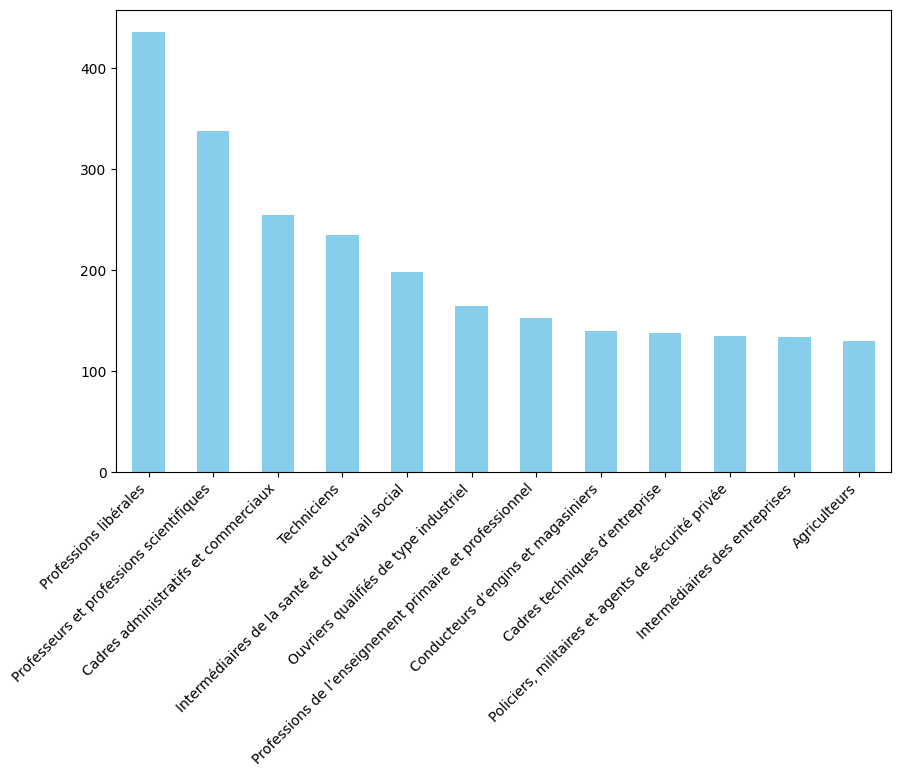

In [30]:
#plot 
counts = df_pred['pcs_n2_lib'].value_counts().head(12)

plt.figure(figsize=(10,6))
counts.plot(kind='bar', color='skyblue')
#plt.title('Distribution des professions selon pcs_n1_libelle')
plt.xlabel("")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Lien avec les thèmes des professions de foi

In [38]:
df=df.merge(
    df_pred[['profession', 'pcs_n1_lib', 'pcs_n2_lib']],
    how='left',  # on garde toutes les lignes de df
    left_on='titulaire-profession',  # colonne dans df
    right_on='profession'           # colonne dans df_pred
)


In [39]:
#df.to_parquet("data/inter/df_lemmatized_5elec.parquet", engine="pyarrow", index=False, compression="snappy")
df = pd.read_parquet("data/inter/df_lemmatized_5elec.parquet")

In [43]:
#proportion de pcs_n1_lib manquants par élection
proportion_none = df.groupby('annee')['profession'].apply(lambda x: x.isna().mean())
print(proportion_none)

annee
1973    0.574811
1978    0.508597
1981    0.560077
1988    0.632099
1993    0.627206
Name: profession, dtype: float64


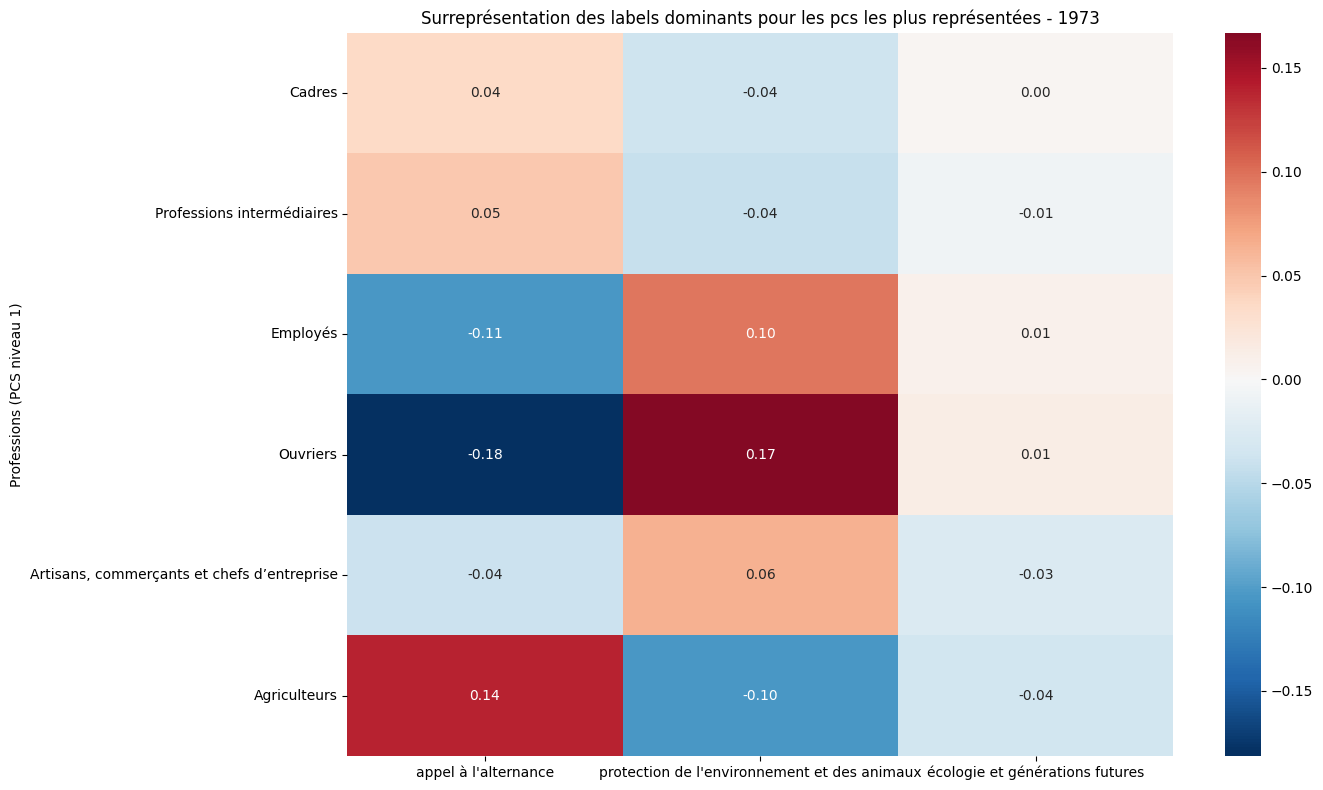

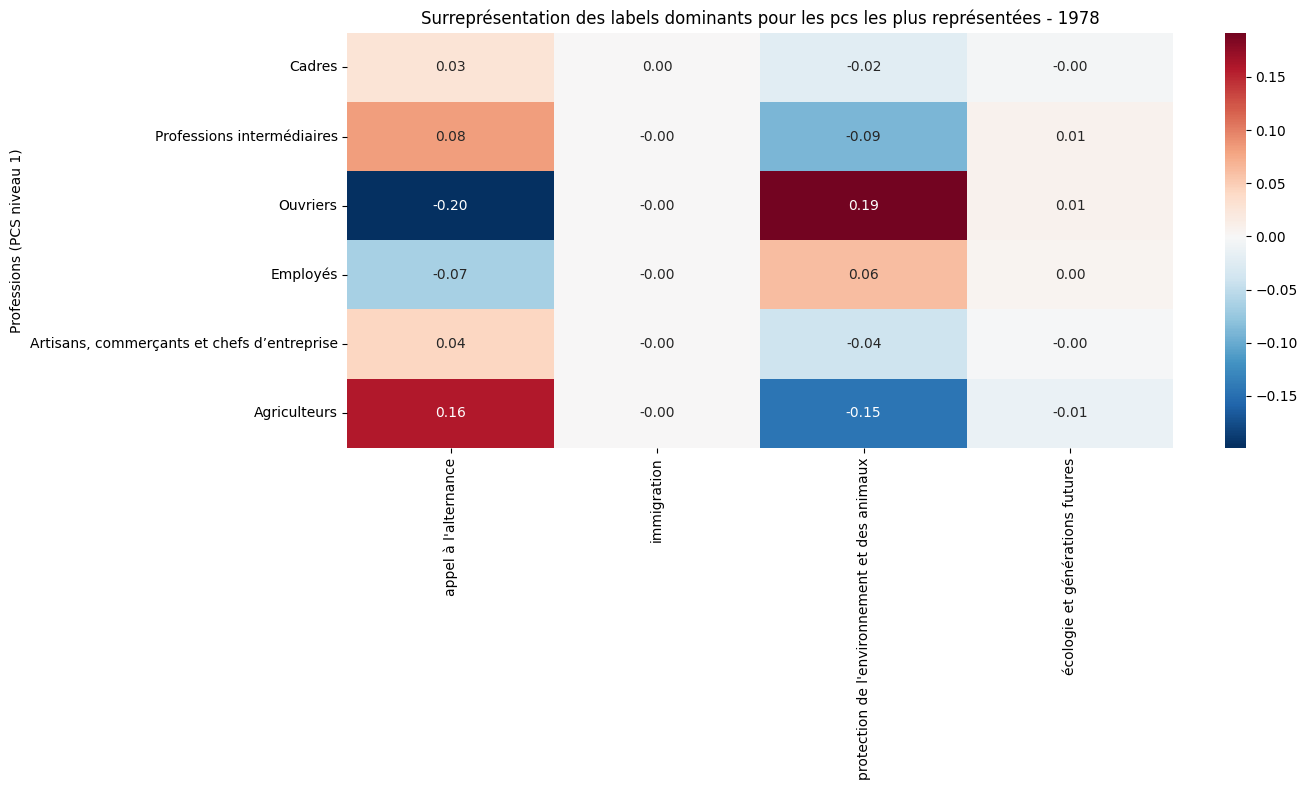

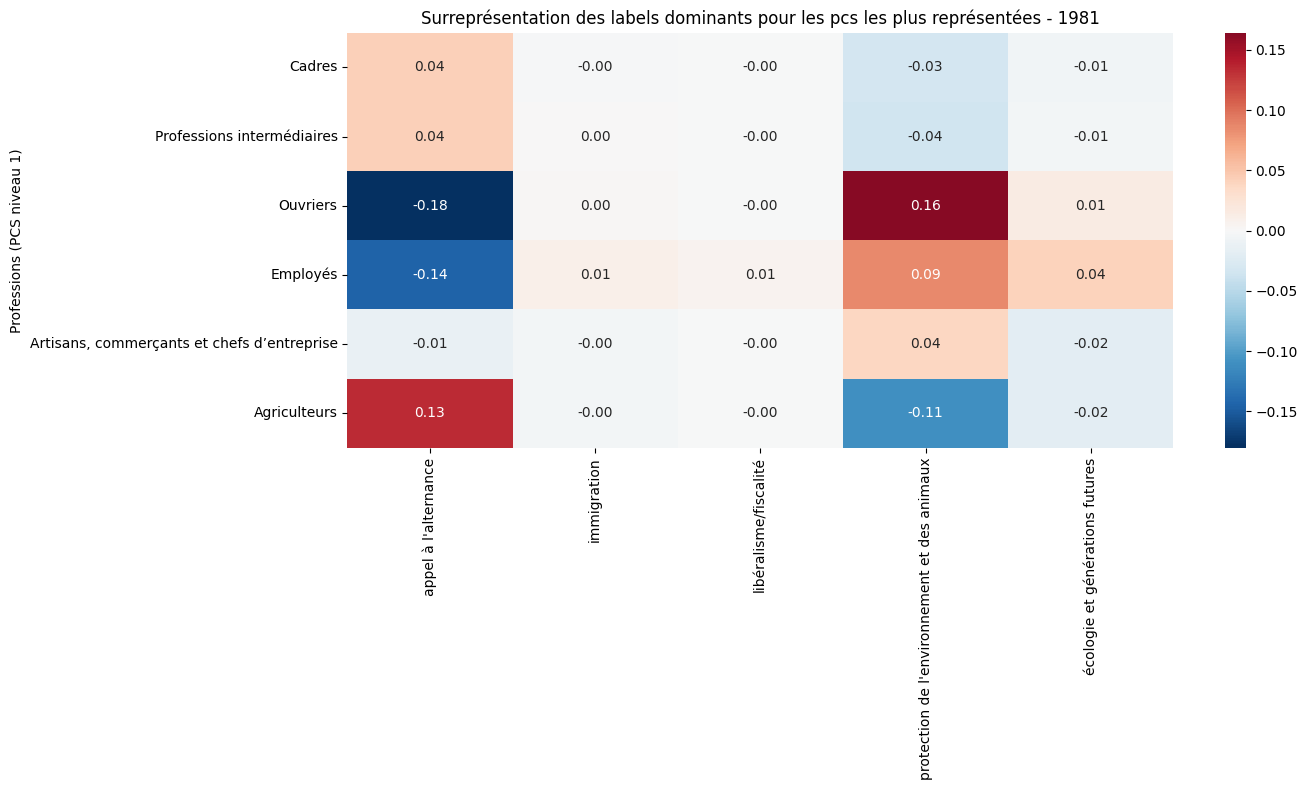

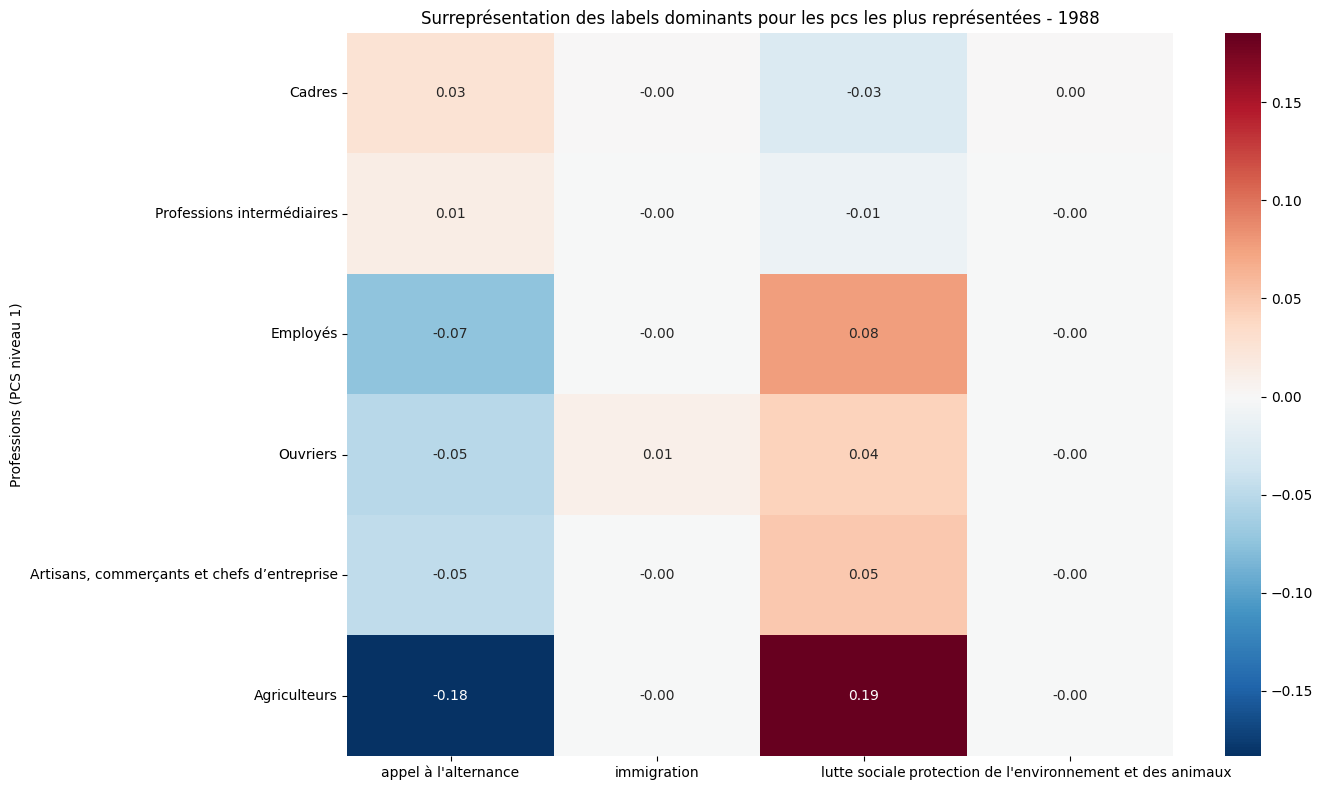

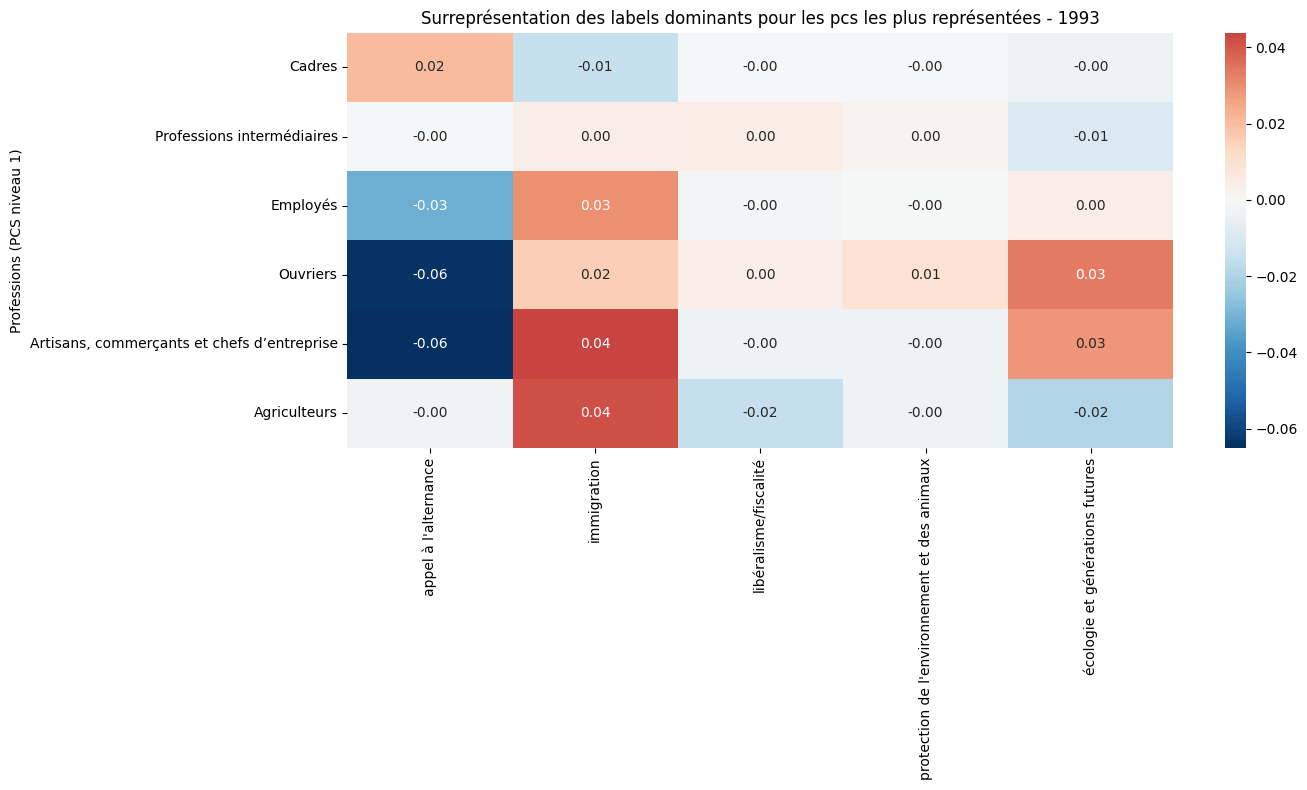

In [50]:
df_plot = df.copy()
df_plot = df_plot[df_plot['dominant_label'].notna()]
df_plot = df_plot[df_plot['dominant_label'] != ""]
df_plot = df_plot[df_plot['dominant_label'] != "non mentionné"]

df_plot = df_plot[df_plot['pcs_n1_lib'].notna()]

for year, df_year in df_plot.groupby('annee'):

    # Computation of the surrepresentation on all the pcs_n1_lib
    global_mean = df_year['dominant_label'].value_counts(normalize=True)
    by_category = df_year.groupby('pcs_n1_lib')['dominant_label'].value_counts(normalize=True).unstack(fill_value=0)
    surreprésentation = by_category - global_mean

    # Select the top 10 PCS represented this year (useful only if pcs_n2)
    top_categories = df_year['pcs_n1_lib'].value_counts().head(10).index
    surreprésentation_top = surreprésentation.loc[top_categories]

    #plot
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        surreprésentation_top,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.title(f"Surreprésentation des labels dominants pour les pcs les plus représentées - {year}")
    plt.xlabel("")
    plt.ylabel("Professions (PCS niveau 1)")
    plt.tight_layout()
    plt.show()

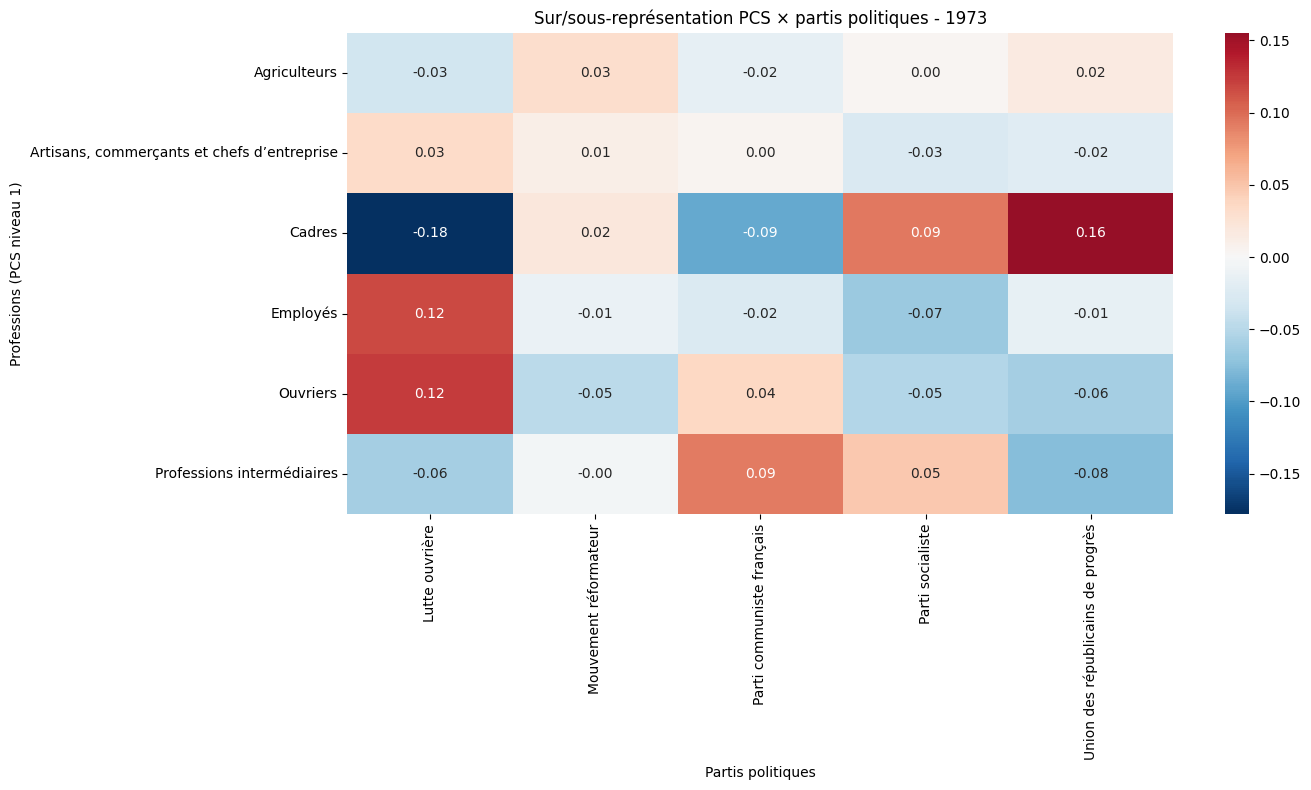

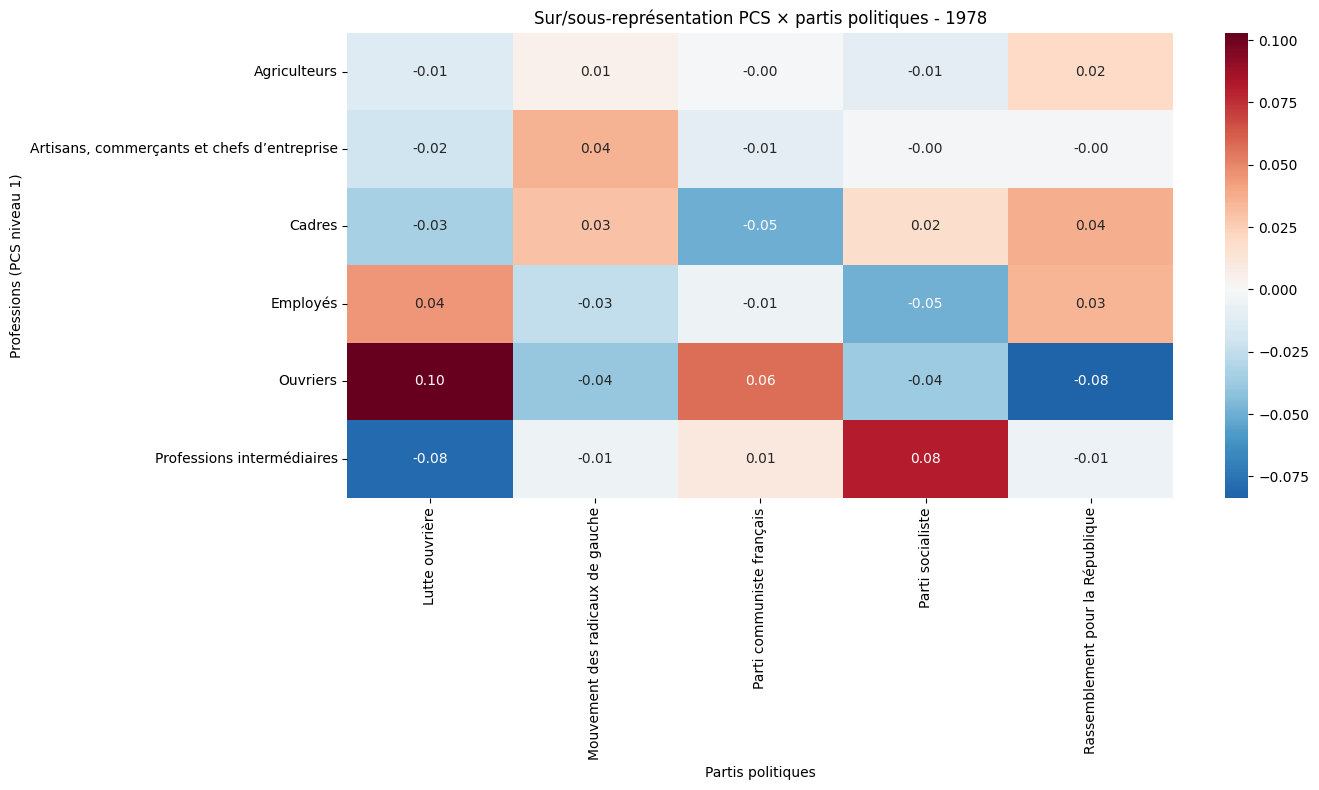

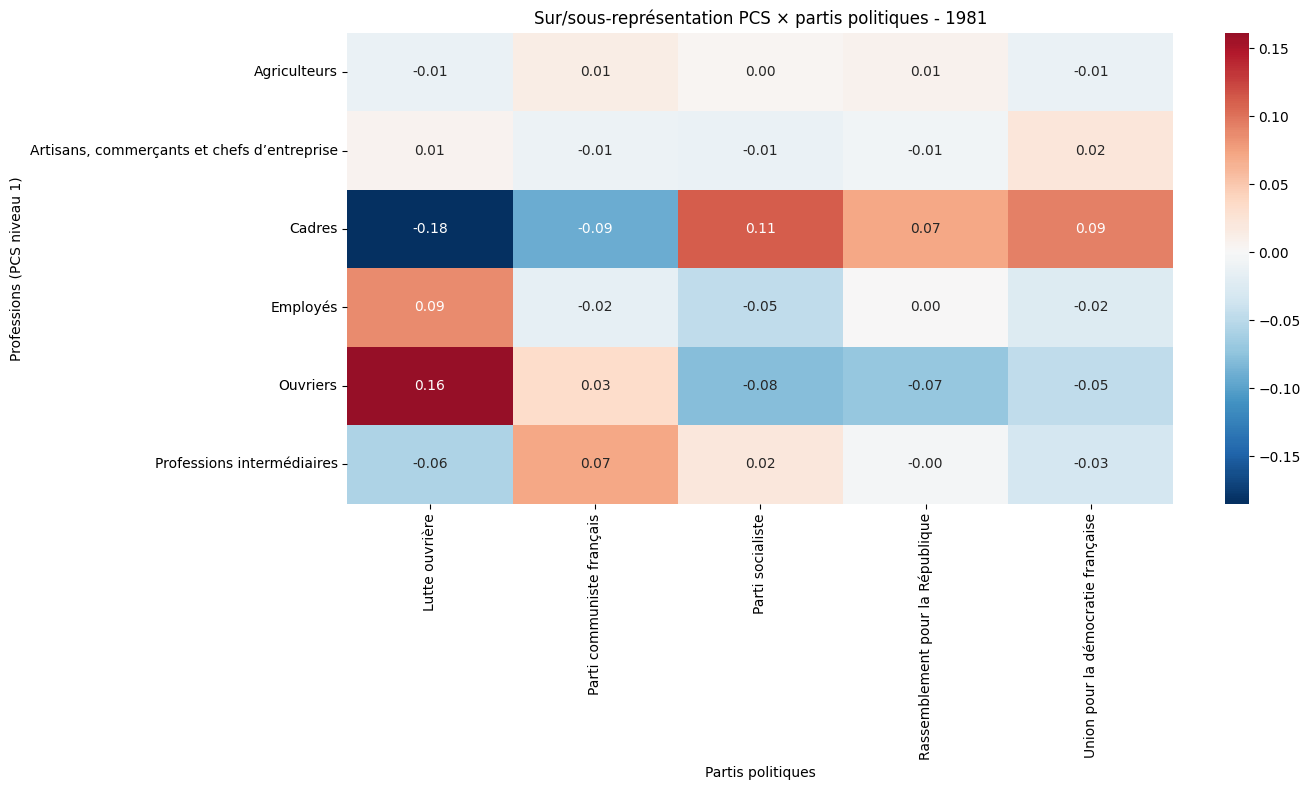

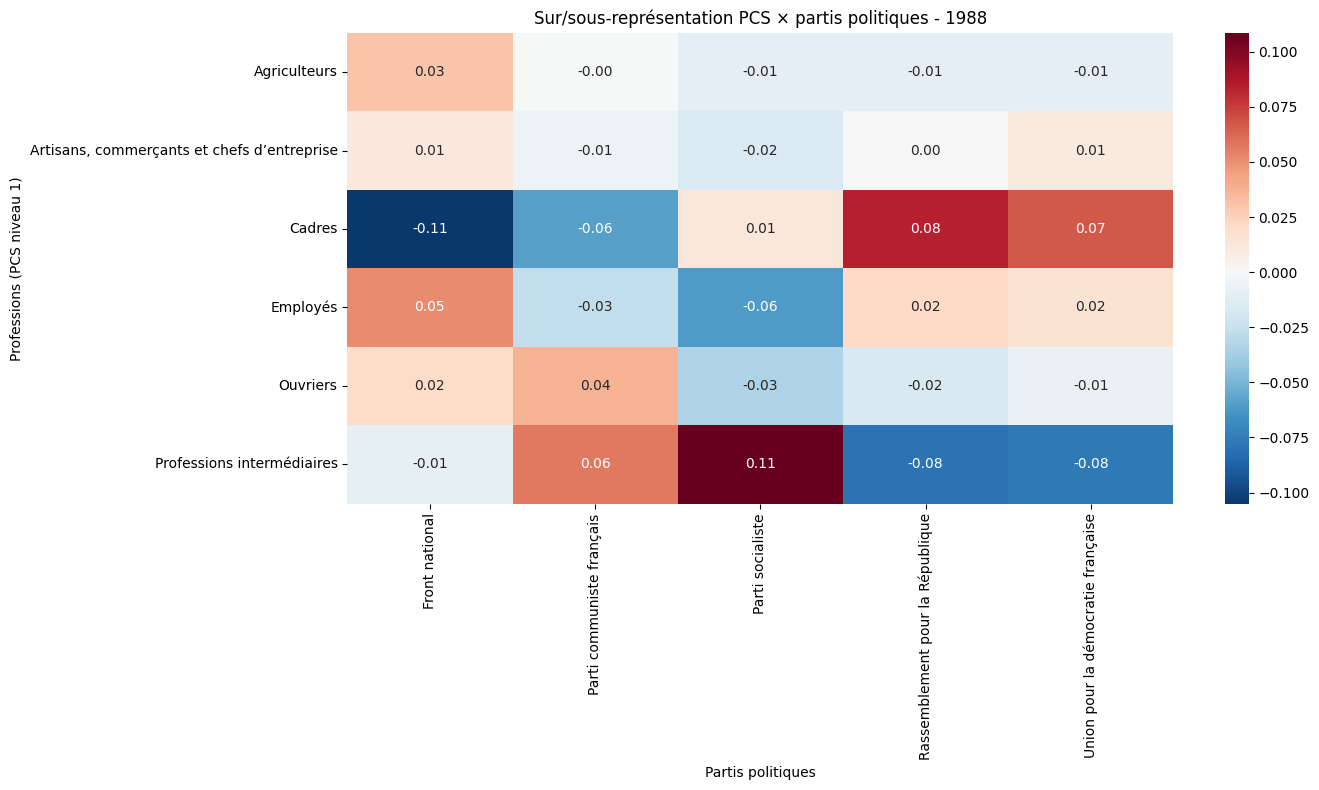

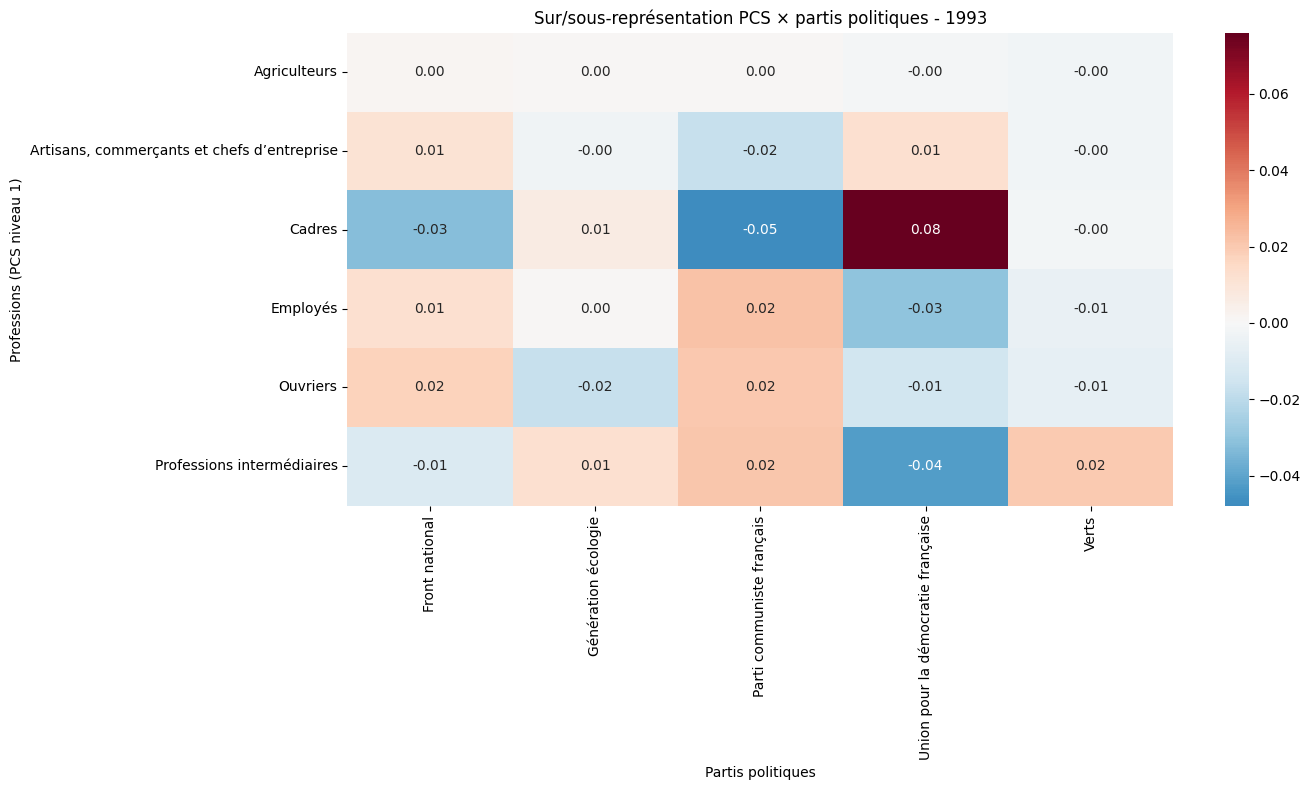

In [47]:
df_plot = df.copy()

# nettoyage partis
df_plot = df_plot[df_plot['titulaire-soutien'].notna()]
df_plot = df_plot[df_plot['titulaire-soutien'] != ""]
df_plot = df_plot[df_plot['titulaire-soutien'] != "non mentionné"]

# nettoyage PCS
df_plot = df_plot[df_plot['pcs_n1_lib'].notna()]

# explode partis
df_plot['parti'] = df_plot['titulaire-soutien'].str.split(';')
df_plot = df_plot.explode('parti')
df_plot['parti'] = df_plot['parti'].str.strip()
df_plot = df_plot[df_plot['parti'] != ""]

for year, df_year in df_plot.groupby('annee'):

    # ---- TOP partis et TOP professions ----
    nb_partis = 5
    nb_pcs = 10

    top_partis = df_year['parti'].value_counts().head(nb_partis).index
    top_pcs = df_year['pcs_n1_lib'].value_counts().head(nb_pcs).index

    df_year = df_year[
        df_year['parti'].isin(top_partis) &
        df_year['pcs_n1_lib'].isin(top_pcs)
    ]

    # ---- table PCS x parti ----
    cross = pd.crosstab(df_year['pcs_n1_lib'], df_year['parti'], normalize='columns')

    # ---- moyenne globale ----
    global_mean = cross.mean(axis=1)

    # ---- surreprésentation ----
    surreprésentation = cross.sub(global_mean, axis=0)

    # ---- heatmap ----
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        surreprésentation,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )

    plt.title(f"Sur/sous-représentation PCS × partis politiques - {year}")
    plt.xlabel("Partis politiques")
    plt.ylabel("Professions (PCS niveau 1)")
    plt.tight_layout()
    plt.show()

## Ancienne version Bert + DBSCAN

In [12]:
df_metier = df[df['titulaire-profession'] != "non mentionné"].copy()
df_metier.shape

(11702, 47)

In [13]:
#small cleaning for jobs
professions = df_metier['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    # we delete the ";" that separates the different professions declared by the same candidate
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

3383

In [ ]:
#Job Embedding (15 sec with camenbert)
model_professions = SentenceTransformer("dangvantuan/sentence-camembert-base")
embeddings_professions = model_professions.encode(unique_professions,
                                                batch_size=256,
                                                show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 529.92it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [00:15<00:00,  1.08s/it]


In [15]:
from sklearn.cluster import KMeans

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings_professions)
prof_cluster_df = pd.DataFrame({
    "profession": unique_professions,
    "cluster": clusters
})

In [16]:
clusterer_prof = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric='euclidean'  # ou mieux: cosine avec normalisation
)

clusters_dbscan = clusterer_prof.fit_predict(embeddings_professions)

prof_cluster_df_dbscan = pd.DataFrame({
    "profession": unique_professions,
    "cluster_dbscan": clusters_dbscan
})

In [17]:
cluster_map = dict(zip(prof_cluster_df_dbscan.profession, prof_cluster_df_dbscan.cluster_dbscan))

df_metier["profession_clean"] = (
    df_metier["titulaire-profession"]
    .str.lower()
    .str.strip()
)

df_metier["profession_cluster"] = (
    df_metier["profession_clean"]
    .map(cluster_map)
)

In [18]:
#Analyse des clusters pour k-means
for i in range(n_clusters):
    print("\nCluster", i)
    print(prof_cluster_df[prof_cluster_df.cluster == i].profession.tolist())


Cluster 0
['délégué médical', 'docteur-vétérinaire', 'médecin chef de service hôpital départemental', 'chirurgien-dentiste', 'docteur en médecine', 'chirurgien directeur clinique chirurgicale', 'docteur en chirurgie dentaire', 'directeur hôpital', 'directeur établissement spécialisé', 'professeur faculté de médecine pharmacie', 'chirurgien chef de service centre hospitalier', 'administrateur centre hospitalier spécialisé', 'médecin généraliste psychosomaticien', 'médecin généraliste', 'professeur cardiologie', 'directeur-adjoint hôpital', 'professeur faculté de médecine', 'médecin spécialiste rééducation fonctionnelle et vertébrothérapie', 'médecin cancérologue', 'médecin ophtalmologiste', 'délégué pharmaceutique', 'médecin spécialiste', 'anesthésiste-réanimateur', 'médecin cardiologue', 'agent hospitalier', 'administrateur hôpital', 'brancardier centre hospitalier', 'professeur faculté de médecine chirurgien hôpitaux chef de service hôpital', 'infirmier domicile', 'docteur en pharmac

In [25]:
#analyse des clusters en dbscan
for cluster_id in sorted(prof_cluster_df_dbscan["cluster_dbscan"].unique()):
    print("\nCluster", cluster_id)
    print(
        prof_cluster_df_dbscan[prof_cluster_df_dbscan.cluster_dbscan == cluster_id]
        .profession
        .tolist()
    )


Cluster -1
['attaché administration universitaire', 'agent de maîtrise', 'technicienne cnrs', 'professeur sciences physiques', 'mission locale', 'employé douanes', 'assistant technique épuration des eaux', 'agent ratp', 'informaticienne', 'docteur-vétérinaire', 'administrateur civil', 'médecin anesthésiste', 'comptable responsable personnel', 'chargé de mission création dentreprises', 'expert-comptable', 'enseignant éducation physique et sportive', 'professeur droit social', 'responsable régional industrie pharmaceutique', 'technicien atelier', 'artisan commerçant', 'professeur histoire médiévale université', 'conseiller environnement', 'secrétaire général entreprise', 'employé banque', 'architecte dplg', 'instituteur', 'greffier en chef', 'éleveur bovins fromager responsable filière transformation des produits', 'education nationale', 'coordinatrice organisme de formation professionnnelle', 'technicien laboratoire', 'docteur expert matériel médical', 'professeur collège directeur ser

In [60]:
cluster_labels = {
0: "fct_publique_admin",
1: "commercant_cadre_commercial",
2: "medical",
3: "legal",
4: "chef_prive",
5: "education_nationale",
6: "armee_aeronautique",
7: "employes_divers",
8: "technicien",
9: "ingenieur",
10: "journaliste",
11: "agriculture"
}

On ajoute les catégories des métiers au dataframe de base

In [61]:
df_metier["profession_category"] = (
    df_metier["profession_cluster"]
    .map(cluster_labels)
)

### Analyse conjointe des sujets des professions de foi et des métiers

In [65]:
df_metier['dominant_label'].head()

2    appel à l'alternance
3    appel à l'alternance
4    appel à l'alternance
8             immigration
9    appel à l'alternance
Name: dominant_label, dtype: object

In [66]:
pd.crosstab(
    df_metier["profession_category"],
    df_metier["dominant_label"],
    normalize="index"
)

dominant_label,appel à l'alternance,immigration,libéralisme/fiscalité,lutte sociale,protection de l'environnement et des animaux,écologie et générations futures
profession_category,,,,,,
agriculture,0.727569,0.059543,0.004078,0.044861,0.137847,0.026101
armee_aeronautique,0.844660,0.048544,0.000000,0.077670,0.024272,0.004854
chef_prive,0.953704,0.027778,0.000000,0.006173,0.006173,0.006173
commercant_cadre_commercial,0.825321,0.052885,0.006410,0.020833,0.073718,0.020833
education_nationale,0.913363,0.014684,0.000000,0.008811,0.041116,0.022026
employes_divers,0.812652,0.043796,0.000000,0.051095,0.072993,0.019465
fct_publique_admin,0.785569,0.047764,0.007114,0.035569,0.094512,0.029472
ingenieur,0.855305,0.070740,0.006431,0.051447,0.000000,0.016077
journaliste,0.810811,0.097713,0.000000,0.064449,0.014553,0.012474


##### Visualisation

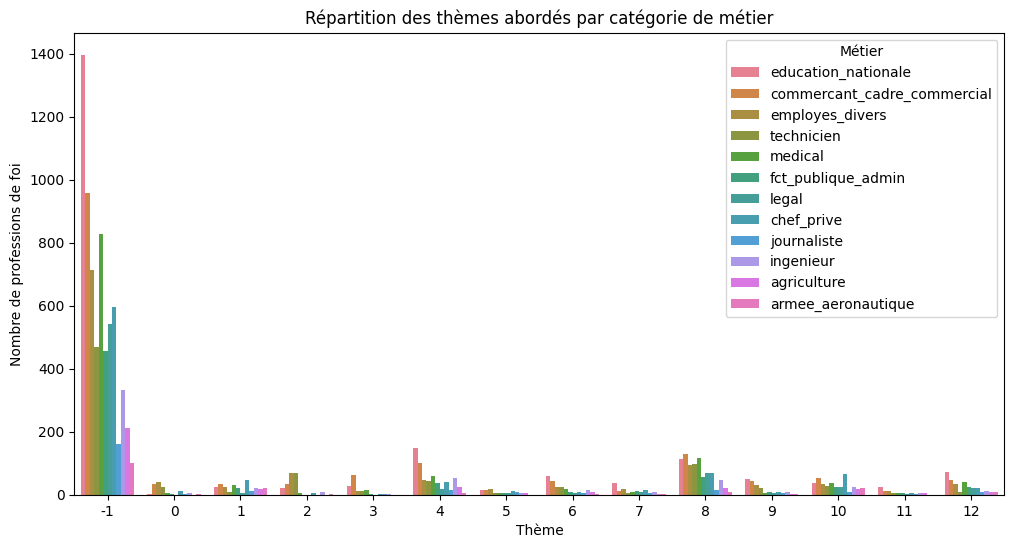

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='theme_cluster', hue='profession_category', data=df_metier)
plt.title("Répartition des thèmes abordés par catégorie de métier")
plt.xlabel("Thème")
plt.ylabel("Nombre de professions de foi")
plt.legend(title="Métier")
plt.show()

In [ ]:

# distribution globale
global_mean = df_plot["dominant_label"].value_counts(normalize=True)

# distribution par catégorie
by_category = (
    df_plot
    .groupby("profession_category")["dominant_label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# surreprésentation
surrepresentation = by_category.subtract(global_mean, axis=1)

# option : top catégories (comme ton code PCS)
top_categories = df_plot["profession_category"].value_counts().head(15).index
surrepresentation_top = surrepresentation.loc[top_categories]

plt.figure(figsize=(14, 8))
sns.heatmap(
    surrepresentation_top,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Surreprésentation des dominant_label par profession_category")
plt.tight_layout()
plt.show()